In [1]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import numpy as np
import pandas as pd

In [2]:
loan_data_backup = pd.read_excel('1. Model Professional Test.xlsx', sheet_name='Dataset')

In [3]:
loan_data_all = loan_data_backup.copy()

In [29]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)     

# missing = loan_data_all.isna().sum()

# print(missing[missing > 0])

# delete 1 row which has lots of missing values. 
# loan_data_all[loan_data_all['gender'].isna()]

loan_data_all = loan_data_all.dropna(subset=['gender'])
# missing = loan_data_all.isna().sum()

# print(missing[missing > 0])

# now we will split into loan_data and loan_data_PSI, (we handle n/a in phone_provider after the split)

# sort by time
loan_data_all = loan_data_all.sort_values('disbursement_date')

# split point (80%)
split_idx = int(len(loan_data_all) * 0.8)

# earlier 80%
loan_data = loan_data_all.iloc[:split_idx]

# latest 20% (for PSI/OOT)
loan_data_PSI = loan_data_all.iloc[split_idx:]

In [48]:
loan_data2= loan_data_PSI.copy()
missing = loan_data2.isna().sum()
print(missing[missing > 0]) 

phone_provider    60
dtype: int64


In [49]:
# loan_data2.info()
# loan_data2.head()
# loan_data2.describe()

In [50]:
loan_data2.shape

(2800, 77)

In [51]:
loan_data2['gender'].unique()

array(['MALE', 'FEMALE', 'Nam'], dtype=object)

In [52]:
loan_data2.loc[loan_data['gender'] == 'Nam', 'gender'] = 'MALE'
loan_data2['gender'].unique()

array(['MALE', 'FEMALE', 'Nam'], dtype=object)

In [53]:
loan_data2['phone_provider'].value_counts(dropna=False)

viettel      1747
mobifone      656
vinaphone     337
NaN            60
Name: phone_provider, dtype: int64

In [54]:
# can replace by mode (viettel in this case) or find 'similar' customers 
#(i.e if missing occupation, can use age and income to guess for occupation)
loan_data2=loan_data2.copy()
loan_data2['phone_provider']= loan_data['phone_provider'].fillna('viettel')

In [55]:
# ADDRESS . you can just run whole code below
x = pd.DataFrame()

# # STEP 1
x['a'] = (
    loan_data2['address_apply']
    .str.extract(r',\s*([^,]+)\s*,\s*[^,]+$')[0]
)

x['a'] = (
    x['a']
    .str.replace(r'\d+', '', regex=True)
    .str.replace(r'\b(Province|Thành phố|City)\b', '', regex=True)
    .str.strip()
)

# if NaN after STEP 1 -> take last 2 words before first comma
x['a'] = x['a'].mask(
    x['a'].isna(),
    loan_data2['address_apply']
    .str.extract(r'([^,]+),')[0] # take text before first comma
    .str.split()  #split into words
    .str[-2:] #take last 2 words
    .str.join(' ') #join back
)

# if '' after STEP 1 -> take 3rd-last part
x['a'] = x['a'].mask(
    x['a'] == '',
    loan_data2['address_apply']
    .str.extract(r',\s*([^,]+)\s*,\s*[^,]+\s*,\s*[^,]+$')[0]
)
# x['a'].unique()

# if data contains 'Hanoi' then "HN"
# if contains 'Province', 'Thành phố', 'City' drop theses words
# if 'Ba Ria - Vung Tau' then "BRVT"
# then give only the first charaters of the word (after drop 'Province', 'Thành phố', 'City') i.e 'An Giang' gives "AG", Ha Noi gives "HN"..

loan_data2['address']= x['a']

# custom replacements
loan_data2['address'] = loan_data2['address'].replace({
    'Hanoi': 'HN',
    'Ha Noi': 'HN',
    'Bà Rịa - Vũng Tàu': 'BRVT',
    'Ba Ria - Vung Tau': 'BRVT',
    'Đồng Nai': 'DNN',
    'Dong Nai': 'DNN',
    'Đà Nẵng': 'DN',
    'Da Nang':'DN',
    'Dak Nong': 'DkN',
    'Đắk Nông': 'DkN'
    
})

loan_data2['address'] = loan_data2['address'].apply(
    lambda x: x
    if x in ['HN', 'BRVT', 'DNN', 'DN', 'DkN']
    else ''.join(word[0] for word in str(x).split()).upper()
)

loan_data2['address'].unique()

array(['QB', 'BD', 'DNN', 'KG', 'HN', 'LA', 'HCM', 'BP', 'QN', 'BRVT',
       'DN', 'QT', 'BG', 'TN', 'NT', 'BN', 'NA', 'TH', 'ND', 'ĐT', 'NĐ',
       'TTH', 'HY', 'TV', 'KH', 'PY', 'TB', 'LĐ', 'NB', 'HD', 'LC', 'BT',
       'PT', 'VP', 'CT', 'VL', 'ST', 'HB', 'BĐ', 'CM', 'TG', 'AG', 'LS',
       'SL', 'CB', 'LD', 'TQ', 'DT', 'HG', 'GL', 'ĐL', 'BL', 'HT', 'BK',
       'YB', 'HP'], dtype=object)

In [38]:
# assume now is May 5
loan_data2['issue_d_date'] = pd.to_datetime(loan_data2['disbursement_date'], format = '%b-%y')

# calculate the month difference from 2026-05-05
# calculate the difference between two dates in months, turn it to numeric datatype and round it.
diff_issue_d = pd.to_datetime('2026-05-05') - loan_data2['issue_d_date']
loan_data2['mths_since_issue_d'] = round(pd.to_numeric( diff_issue_d / np.timedelta64(1, 'M')))

# loan_data2['mths_since_issue_d'].describe() 

In [39]:
### HANDLE CONT FEATURES

In [40]:
upper_limit=loan_data2['month_incom'].mean() + 3 * loan_data2['month_incom'].std()
loan_data2['month_incom'] = loan_data2['month_incom'].clip(upper=upper_limit)
# loan_data2.describe()

In [41]:
# #We see that min value of OUTS_BAL_CC_M1-12 are -1 -> notcorrect-> replace by 0
loan_data2 = loan_data2.copy()
cols_cc = [f'OUTS_BAL_CC_M{i}' for i in range(1, 13)]
loan_data2[cols_cc] = loan_data2[cols_cc].replace(-1, 0)

# (loan_data2['OUTS_BAL_LOAN_M1'] + loan_data2['OUTS_BAL_CC_M1'] == loan_data2['OUTS_BAL_ALL_M1']).all() #check -> false

# loan_data2 = loan_data2.copy()
# for i in range(1, 13):
#     loan = loan_data2[f'OUTS_BAL_LOAN_M{i}']
#     cc   = loan_data2[f'OUTS_BAL_CC_M{i}']
#     all_ = loan_data2[f'OUTS_BAL_ALL_M{i}']

#     test = loan + cc - all_

#     # if test < 0 → update CC, else update ALL
#     loan_data2[f'OUTS_BAL_CC_M{i}'] = np.where(test < 0, -test, cc)
#     loan_data2[f'OUTS_BAL_ALL_M{i}'] = np.where(test > 0, loan + cc, all_)
# #     (loan_data2['OUTS_BAL_LOAN_M12'] + loan_data2['OUTS_BAL_CC_M12'] == loan_data2['OUTS_BAL_ALL_M12']).all()
# #check -> result: false

# all(
#     (
#         loan_data2[f'OUTS_BAL_LOAN_M{i}'] +
#         loan_data2[f'OUTS_BAL_CC_M{i}']
#         == loan_data2[f'OUTS_BAL_ALL_M{i}']
#     ).all()
#     for i in range(1, 13)
# ) #> result: true

for i in range(1, 13):
    loan = loan_data2[f'OUTS_BAL_LOAN_M{i}']
    cc   = loan_data2[f'OUTS_BAL_CC_M{i}']
    all_ = loan_data2[f'OUTS_BAL_ALL_M{i}']

    print(
        f'M{i}:',
        'loan min =', loan.min(),
        '| cc min =', cc.min(),
        '| all min =', all_.min()
    )
    
loan_data2['OUTS_BAL_CC_CURRENT']=np.where( loan_data2['OUTS_BAL_CC_CURRENT'] < 0,0,loan_data2['OUTS_BAL_CC_CURRENT'])
# loan_data2['OUTS_BAL_CC_CURRENT'].describe()

df = loan_data2.copy()

M1: loan min = 0 | cc min = 0 | all min = 0
M2: loan min = 0 | cc min = 0 | all min = 0
M3: loan min = 0 | cc min = 0 | all min = 0
M4: loan min = 0 | cc min = 0 | all min = 0
M5: loan min = 0 | cc min = 0 | all min = 0
M6: loan min = 0 | cc min = 0 | all min = 0
M7: loan min = 0 | cc min = 0 | all min = 0
M8: loan min = 0 | cc min = 0 | all min = 0
M9: loan min = 0 | cc min = 0 | all min = 0
M10: loan min = 0 | cc min = 0 | all min = 0
M11: loan min = 0 | cc min = 0 | all min = 0
M12: loan min = 0 | cc min = 0 | all min = 0


In [42]:
# i. HANDLE OUTLIERS: 

# # clip at 1% and 99%

cols = []

for i in range(1, 13):
    cols.extend([
        f'OUTS_BAL_ALL_M{i}',
        f'OUTS_BAL_CC_M{i}',
        f'OUTS_BAL_LOAN_M{i}'
    ])

cols.extend([
    'OUTS_BAL_CC_CURRENT',
    'CC_LIMIT_TOTAL'
])

# clip at 1st and 99th percentile
for col in cols:
    p1  = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(p1, p99)
loan_data2 = df
# loan_data2.describe()

In [43]:
# loan_data2['Age'].unique()

# loan_data2[loan_data2['Age'] == 124] #couldbe error

# loan_data2['Age']= loan_data2['Age'].replace(124, 24) #replace by median
df=loan_data2.loc[loan_data2['Age'] != 124, ['Age', 'occupation']] #replace using occupation

df = df.groupby('occupation')['Age'].agg(
    mean='mean',
    median='median',
    mode=lambda x: x.mode().iloc[0] if not x.mode().empty else None
)

# df.head()
# create mapping: occupation -> median Age
median_map = df['median']

# replace only rows where Age = 124
mask = loan_data2['Age'] == 124

loan_data2.loc[mask, 'Age'] = loan_data2.loc[mask, 'occupation'].map(median_map)

# loan_data2.head() 
# loan_data2.describe()

In [44]:
#target. imblanced data set
loan_data2['FPD10+'].unique()

loan_data2['DPD10_3MOB'].unique()

array([1, 0], dtype=int64)

In [45]:
# loan_data2.iloc[:, [9,10]].apply(lambda x: x.value_counts(normalize=True).mul(100)).plot.bar(figsize=(3,2)) #show in percentage

# y = ((loan_data2['FPD10+'] == 1) | (loan_data2['DPD10_3MOB'] == 1)).astype(int)
y = loan_data2['FPD10+']
# Imbalance checking
y.value_counts(normalize=True) 

0    0.911786
1    0.088214
Name: FPD10+, dtype: float64

In [46]:
# drop columns: customer_id, address_apply   , FPD10+  , DPD10_3MOB, CIC_DATA   , disbursement_date', 'issue_d_date'
# loan_data2.columns = loan_data2.columns.str.strip()
cols = ['customer_id', 'address_apply',  'CIC_DATA', 'disbursement_date', 'issue_d_date','FPD10+', 'DPD10_3MOB']#
loan_data2 = loan_data2.drop(columns=cols, errors='ignore')

loan_data2.head()

,Age,gender,occupation,month_incom,operating_system,phone_provider,SHORT_TERM_AMOUNT,MID_TERM_AMOUNT,LONG_TERM_AMOUNT,SHORT_TERM_COUNT,MID_TERM_COUNT,LONG_TERM_COUNT,SHORT_TERM_COUNT_BANK,MID_TERM_COUNT_BANK,LONG_TERM_COUNT_BANK,SHORT_TERM_COUNT_NON_BANK,MID_TERM_COUNT_NON_BANK,LONG_TERM_COUNT_NON_BANK,NUM_LOANS,NUM_LOANS_BANK,NUM_LOANS_NON_BANK,NUM_CC,NUM_CC_BANK,NUM_CC_NON_BANK,NUM_RELATIONSHIP,OUTS_BAL_LOAN_M1,OUTS_BAL_CC_M1,OUTS_BAL_ALL_M1,OUTS_BAL_LOAN_M2,OUTS_BAL_CC_M2,OUTS_BAL_ALL_M2,OUTS_BAL_LOAN_M3,OUTS_BAL_CC_M3,OUTS_BAL_ALL_M3,OUTS_BAL_LOAN_M4,OUTS_BAL_CC_M4,OUTS_BAL_ALL_M4,OUTS_BAL_LOAN_M5,OUTS_BAL_CC_M5,OUTS_BAL_ALL_M5,OUTS_BAL_LOAN_M6,OUTS_BAL_CC_M6,OUTS_BAL_ALL_M6,OUTS_BAL_LOAN_M7,OUTS_BAL_CC_M7,OUTS_BAL_ALL_M7,OUTS_BAL_LOAN_M8,OUTS_BAL_CC_M8,OUTS_BAL_ALL_M8,OUTS_BAL_LOAN_M9,OUTS_BAL_CC_M9,OUTS_BAL_ALL_M9,OUTS_BAL_LOAN_M10,OUTS_BAL_CC_M10,OUTS_BAL_ALL_M10,OUTS_BAL_LOAN_M11,OUTS_BAL_CC_M11,OUTS_BAL_ALL_M11,OUTS_BAL_LOAN_M12,OUTS_BAL_CC_M12,OUTS_BAL_ALL_M12,CC_LIMIT_TOTAL,OUTS_BAL_CC_CURRENT,ENQ_3M,ENQ_6M,ENQ_9M,ENQ_12M,NUM_NEW_LOAN_3M,NUM_NEW_LOAN_6M,NUM_NEW_LOAN_9M,NUM_NEW_LOAN_12M,address,mths_since_issue_d
11223,23,MALE,FREELANCER,12000000.0,ANDROID,viettel,19,0,0,2,0,0,1,0,0,1,0,0,2,1,1,0,0,0,2,19.0,0.0,19.0,21.0,0.0,21.0,23.0,0,23.0,4,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0.00,0.0,0.0,0.0,2,2,2,2,0,2,2,2,QB,23.0
11224,25,MALE,WORKER,10000000.0,ANDROID,viettel,16,0,0,4,0,0,2,0,0,2,0,0,4,2,2,1,1,0,5,16.0,0.0,16.0,18.0,0.0,18.0,20.0,0,20.0,21,0.0,21.0,23.0,0.0,23.0,20.0,0.0,20.0,15.0,15.0,30.0,11.0,16.0,27.0,0.0,17.0,17.0,0.0,19.0,19.0,0.0,0,0.0,0,0.00,0.0,1.0,0.0,2,3,4,4,2,2,4,4,BD,23.0
10075,28,MALE,WORKER,15000000.0,IOS,viettel,21,49,0,2,1,0,1,1,0,1,0,0,3,2,1,5,5,0,8,74.0,214.0,288.0,68.0,212.0,280.0,72.0,211,283.0,72,210.0,282.0,76.0,209.0,285.0,83.0,203.0,286.0,85.0,202.0,287.0,85.0,202.0,287.0,90.0,203.0,293.0,93.0,203.0,296.0,96.0,234,359.0,99,222.04,357.0,267.0,214.0,4,8,10,15,1,1,3,3,DNN,23.0
10947,32,MALE,Business_Households,7608006.0,IOS,vinaphone,6,48,0,1,1,0,0,1,0,1,0,0,2,1,1,0,0,0,2,56.0,0.0,56.0,29.0,0.0,29.0,32.0,0,32.0,33,0.0,33.0,38.0,0.0,38.0,41.0,0.0,41.0,44.0,0.0,44.0,47.0,0.0,47.0,35.0,0.0,35.0,37.0,0.0,37.0,40.0,0,40.0,42,0.00,42.0,0.0,0.0,2,2,2,2,1,1,2,2,KG,23.0
11095,19,MALE,STUDENT,5000000.0,IOS,viettel,8,0,0,1,0,0,0,0,0,1,0,0,1,0,1,1,1,0,2,8.0,0.0,8.0,9.0,1.0,10.0,10.0,0,10.0,11,0.0,11.0,12.0,0.0,12.0,12.0,1.0,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0,0.00,0.0,10.0,0.0,1,1,1,1,0,1,1,1,HN,23.0


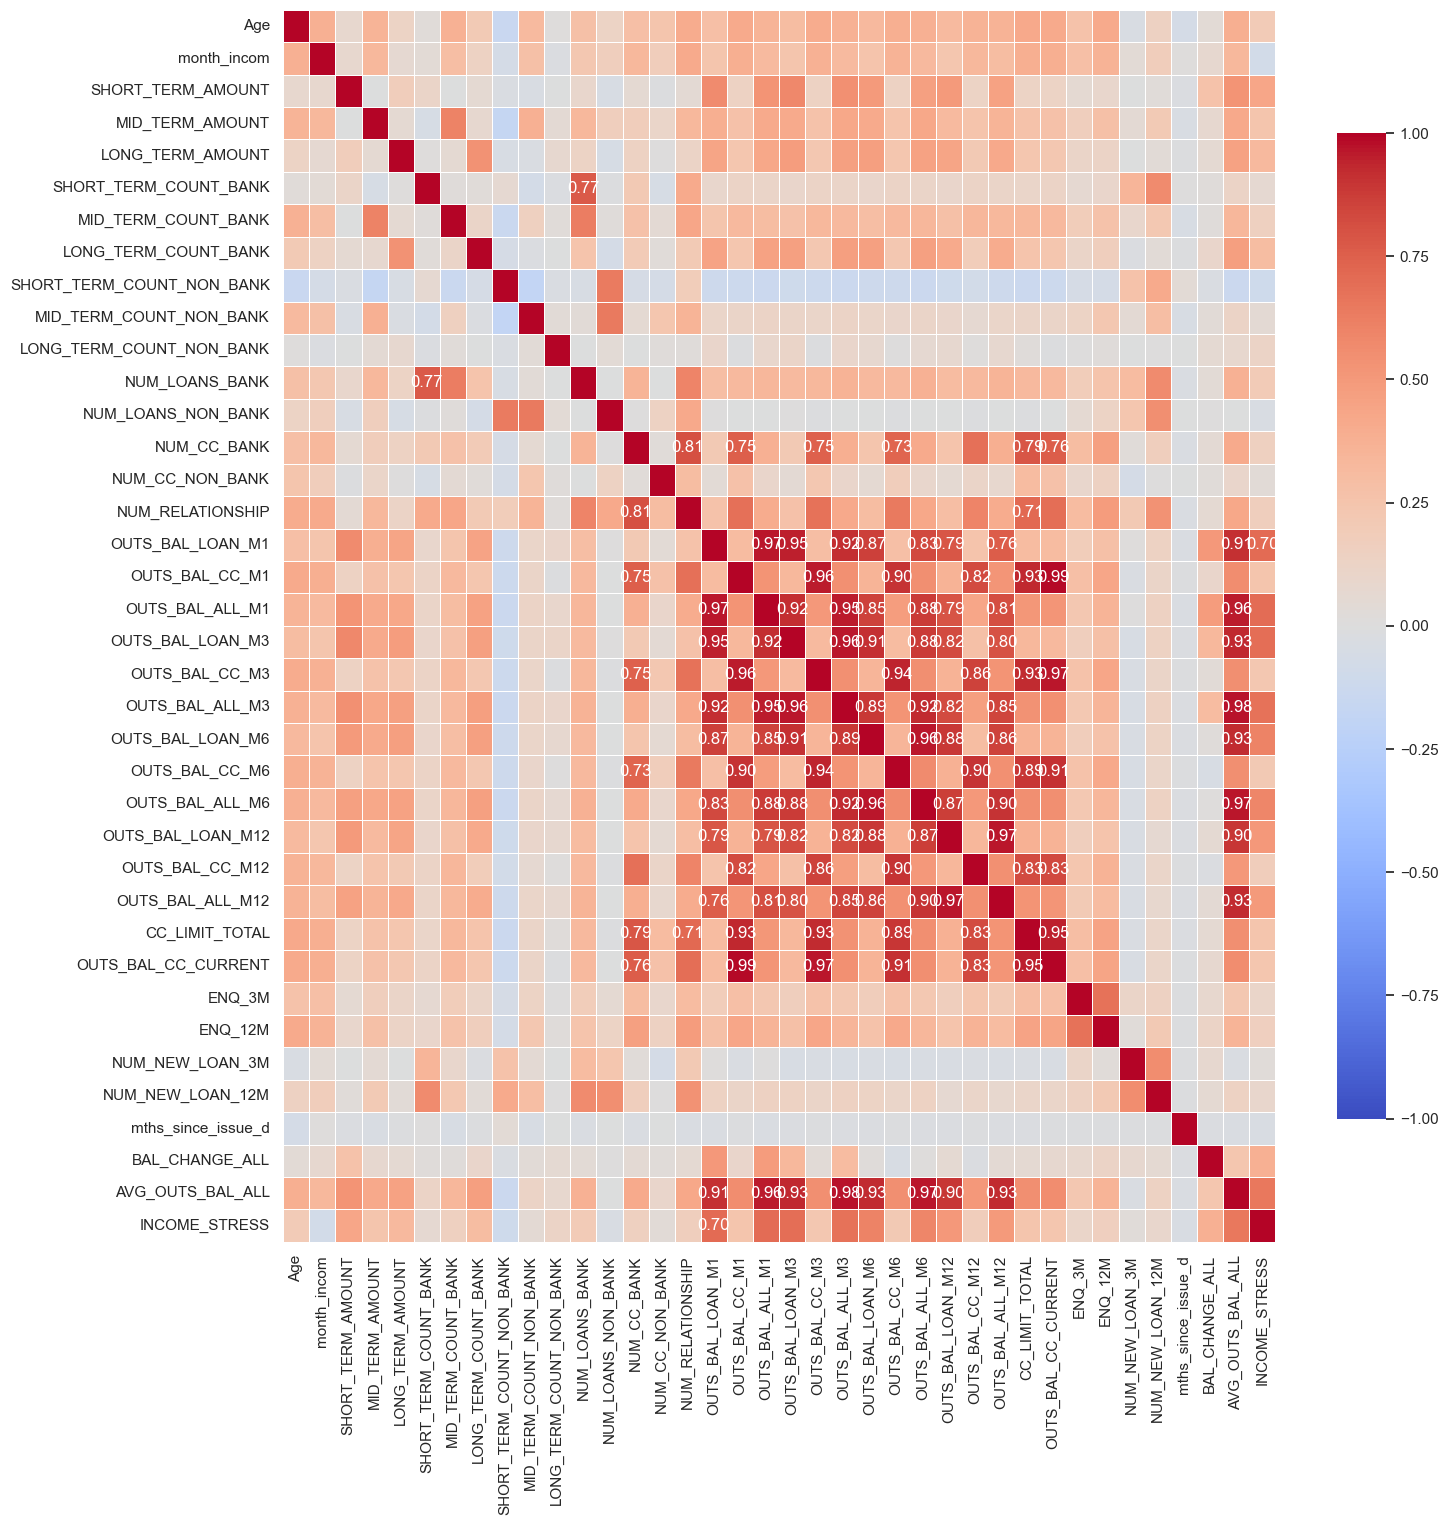

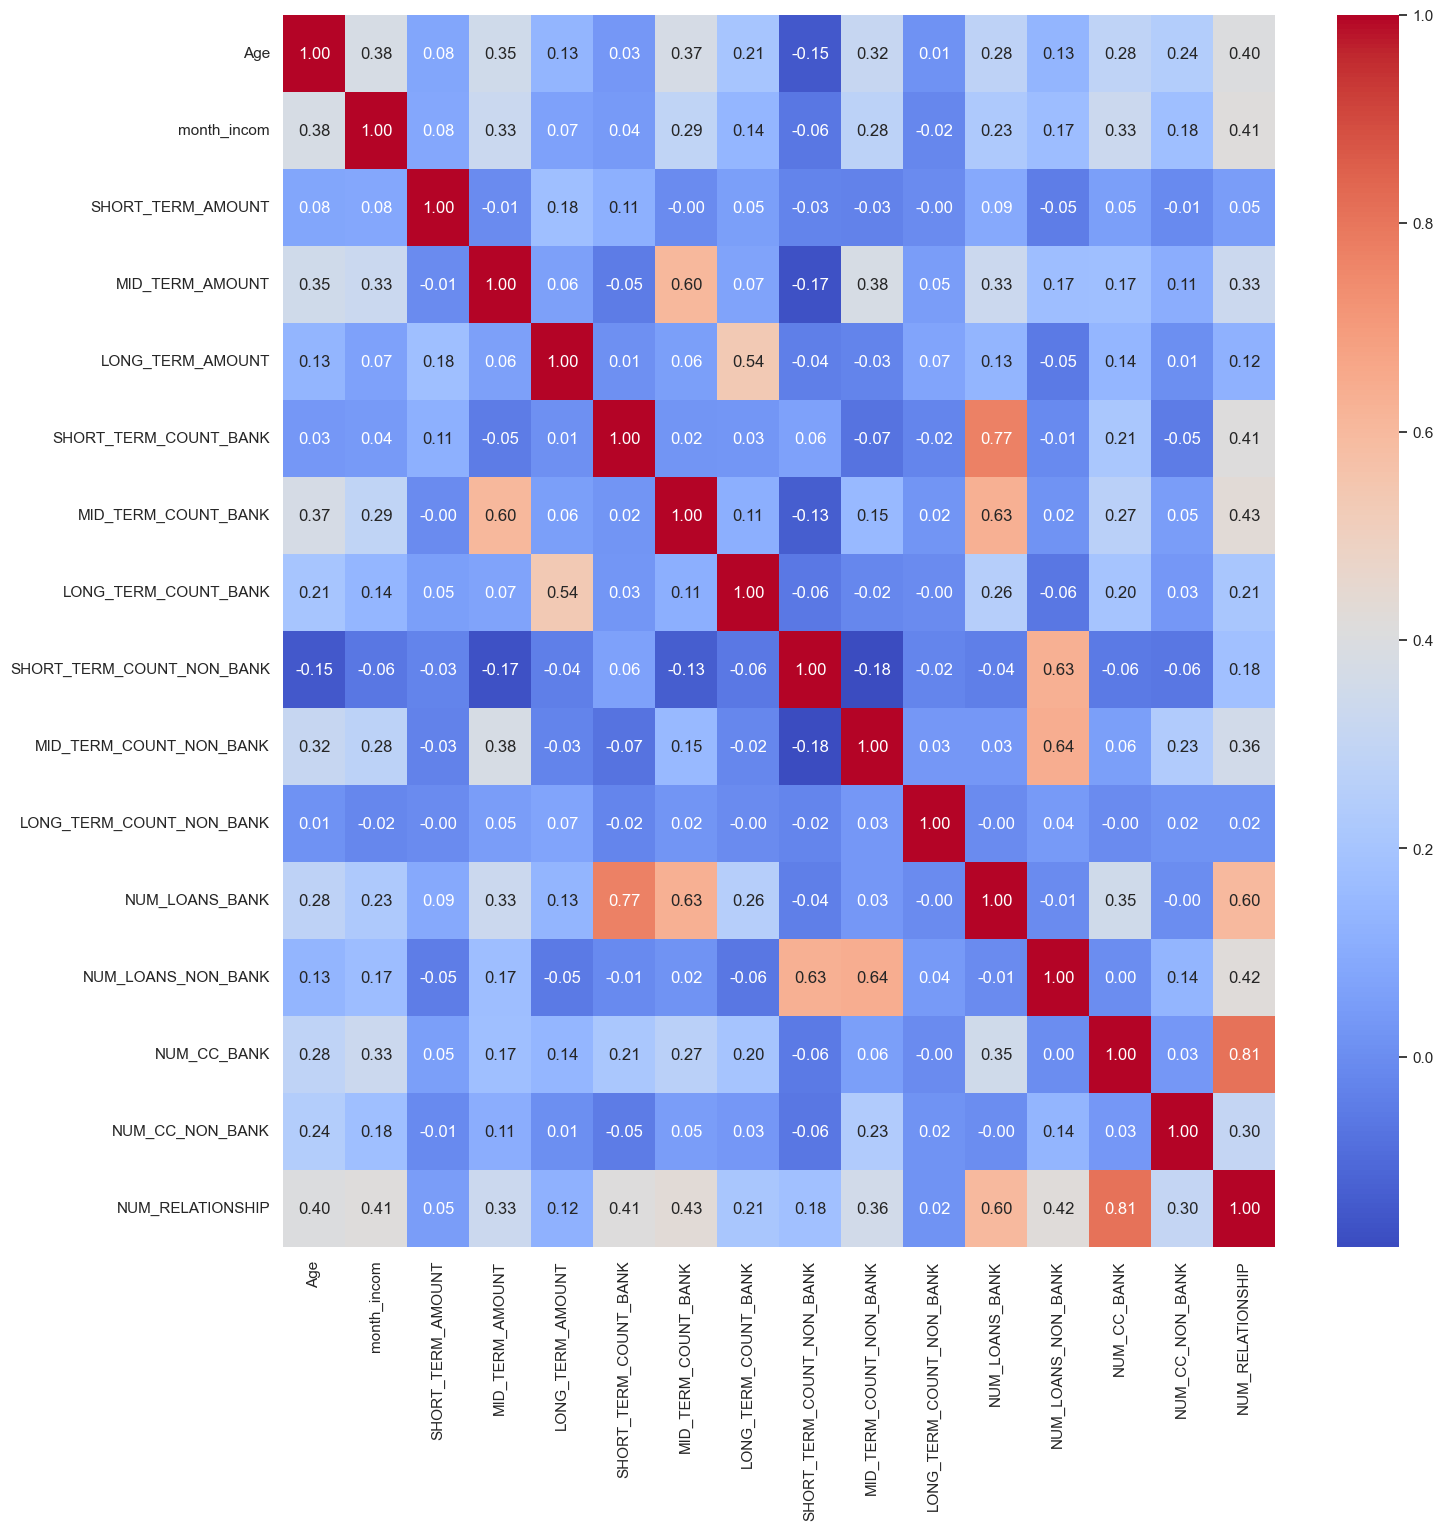

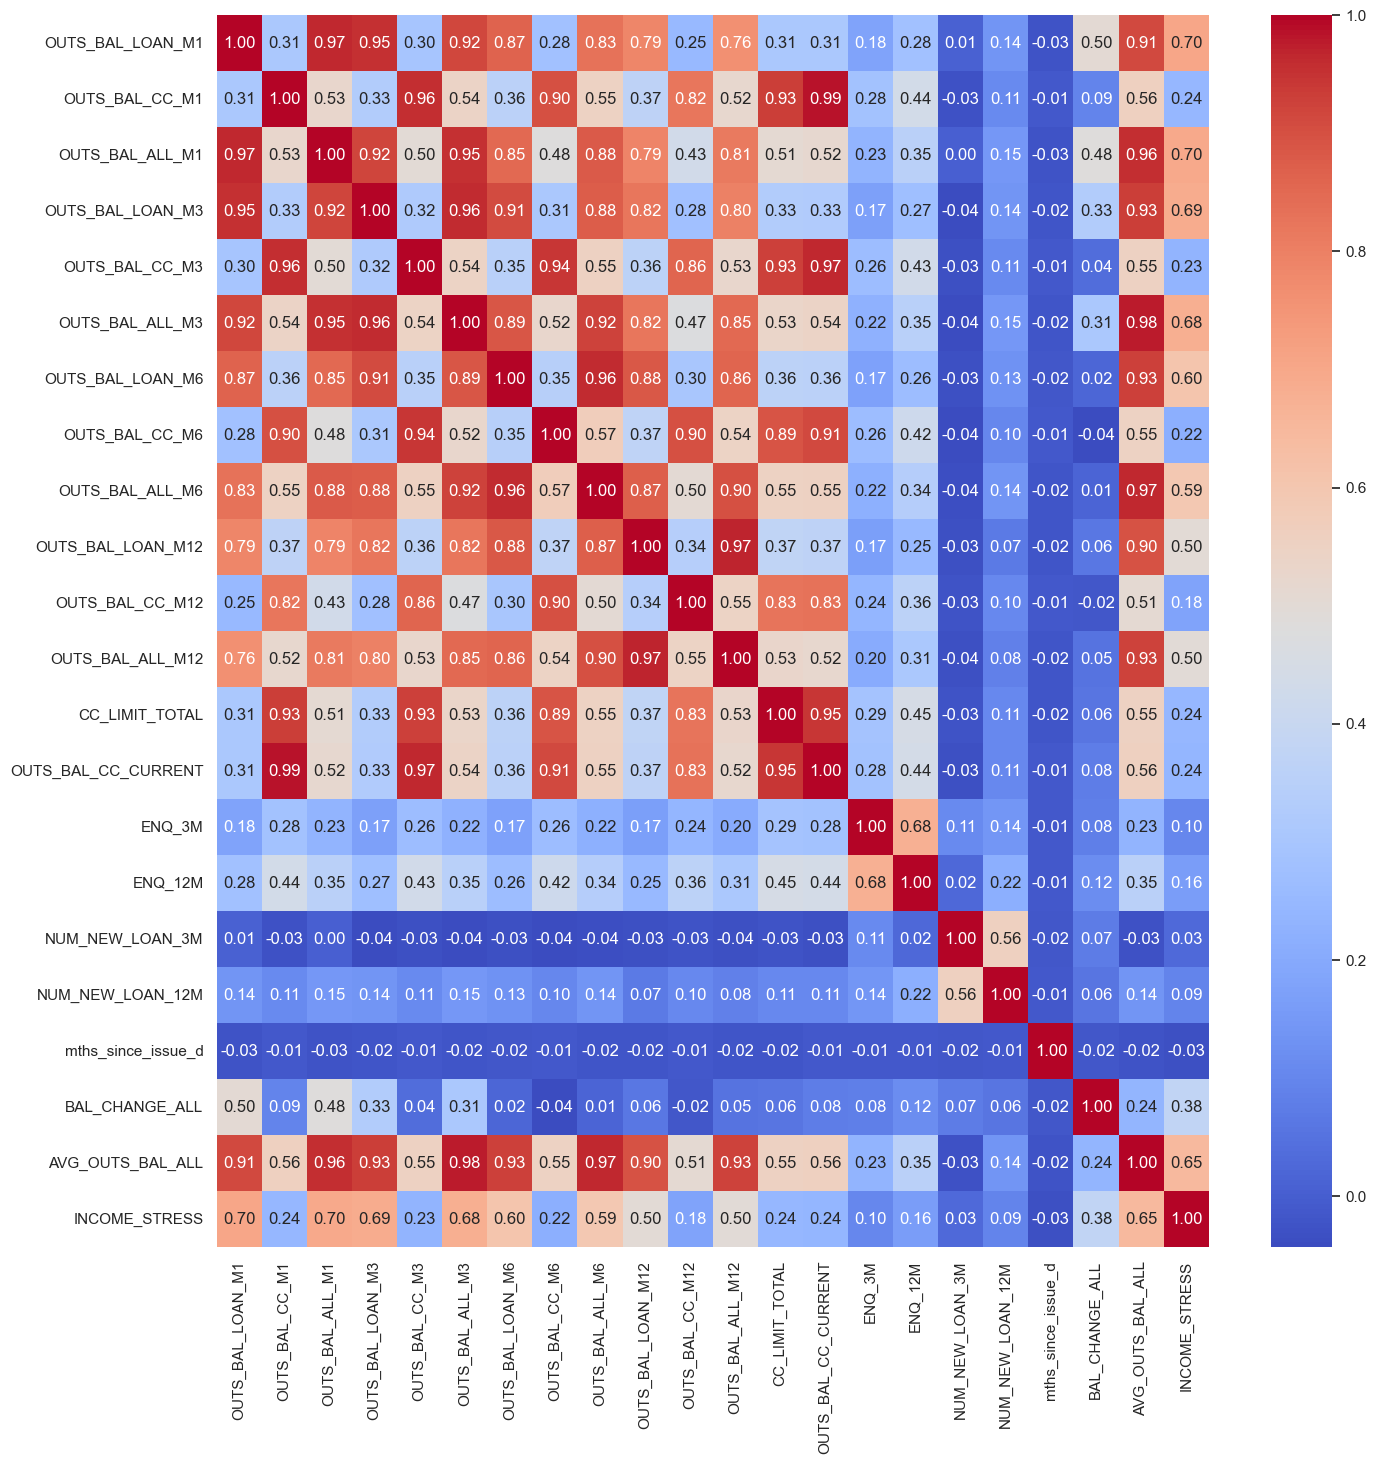

In [47]:
#  OUTLIER n FEATURE ENGINEERING

''''
i. OUTLIERS (already)
ii.ENGINEER:

2. LOAN: Bank vs Non-Bank Splits
NUM_LOANS_BANK + NUM_LOANS_NON_BANK = NUM_LOANS → drop NUM LOAN bcz the SOURCE of the debt is a signal of risk
SHORT/MID/LONG_TERM_COUNT → likely correlated with NUM_LOANS; keep counts or NUM_LOANS + term breakdown, not both

Same for NUM_CC_BANK/NON_BANK, term counts

3. CC
Keep NUM_CC_BANK,NUM_CC_NON_BANK, remove NUM_CC (source of CC may be important)

ratio maybe more predictive: Utilization: OUTS_BAL_CC_CURRENT / CC_LIMIT_TOTAL
If CC_LIMIT_TOTAL is 0 but OUTS_BAL_CC_CURRENT is greater than 0 
(e.g., a closed account with a remaining balance), the ratio is technically infinite -> set ratio = 0 in case CC_.. = 0
but i check that >3000 values 0 for CC_LIMIT_TOAL so I do not create this col.

4.OUTS: 
For groups like OUTS_BAL_*_M1→12, may not keep all 12 months. Instead:

Keep a few time points: M1 (recent), M3, M6, M12 (trend anchor)
Engineer trend features: BAL_CHANGE = M1 - M6, AVG. (possible: BAL_TREND = M1/M12, but handle cases M12 = 0.not use it here)
Pick one: OUTS_BAL_ALL = LOAN + CC separately -> pick LOAN, CC and ALL
Income Stress: OUTS_BAL_ALL_M1 / MONTH_INCOM. check data: income  not = 0 so ok (otherwise handle that cases)
but OUT_BAL_ALL_M1 = 0 for 3000+ values ->may..?

5. Keep ENQ_3M (recent stress) and ENQ_12M (long-term behavior)
6. rela: drop :NUM_NEW_LOAN_6M, NUM_NEW_LOAN_9M. keep the recent n longest history (3M, 12M)
'''

#remove: ENQ_6M, NUM LOANS,...

# =========================
# ii. FEATURE ENGINEERING

# ---- Drop features
df= loan_data2
drop_cols = [
    'NUM_LOANS',
    'SHORT_TERM_COUNT',
    'MID_TERM_COUNT',
    'LONG_TERM_COUNT',
    'NUM_CC',
    'ENQ_6M',
    'ENQ_9M',
    'NUM_NEW_LOAN_6M',
    'NUM_NEW_LOAN_9M'
]

df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# ---- Credit card utilization:  i tried but took a lot of time so i gave up
# df['UTILIZATION_CC'] = df['OUTS_BAL_CC_CURRENT'] / df['CC_LIMIT_TOTAL']

# df['UTILIZATION_CC'] =  np.where(
# df['CC_LIMIT_TOTAL'] > 0,
# df['OUTS_BAL_CC_CURRENT'] / df['CC_LIMIT_TOTAL'],
# 0)

# ---- Trend features (using ALL balance)
df['BAL_CHANGE_ALL'] = (
    df['OUTS_BAL_ALL_M1'] - df['OUTS_BAL_ALL_M6']
)

df['AVG_OUTS_BAL_ALL'] = df[
    ['OUTS_BAL_ALL_M1','OUTS_BAL_ALL_M3',
     'OUTS_BAL_ALL_M6','OUTS_BAL_ALL_M12']
].mean(axis=1)
# ---- Keep only M1, M3, M6, M12
drop_m_cols = []

for prefix in ['OUTS_BAL_LOAN_', 'OUTS_BAL_CC_', 'OUTS_BAL_ALL_']:
    for i in [2,4,5,7,8,9,10,11]:
        col = f'{prefix}M{i}'
        if col in df.columns:
            drop_m_cols.append(col)

df.drop(columns=drop_m_cols, inplace=True)

# ---- Income stress
df['INCOME_STRESS'] = np.where(
    df['month_incom'] != 0,
    df['OUTS_BAL_ALL_M1'] / df['month_incom'],
    0
)

# final dataset
loan_data2_fe = df

# loan_data2_fe.describe()
# loan_data2_fe.columns

corr = loan_data2_fe.corr(numeric_only=True) #check corr of whold dataset so we use loan_data2_fe

# Create a version of the correlation matrix where values < 0.7 are empty strings
annot_mask = corr.applymap(lambda x: f'{x:.2f}' if 0.7 <= abs(x) < 1 else "")

plt.figure(figsize=(16, 16))

sns.heatmap(
    corr, 
    annot=annot_mask,   # Use our filtered strings for annotations
    fmt="",             # Format must be empty because we pre-formatted the strings
    cmap='coolwarm', 
    linewidths=0.5,
    vmin=-1, vmax=1,    # Ensure the scale is always -1 to 1
    cbar_kws={"shrink": .8}
)
plt.show()

cols = ['Age', 'gender', 'occupation', 'month_incom', 'operating_system',
       'phone_provider', 'SHORT_TERM_AMOUNT', 'MID_TERM_AMOUNT',
       'LONG_TERM_AMOUNT', 'SHORT_TERM_COUNT_BANK', 'MID_TERM_COUNT_BANK',
       'LONG_TERM_COUNT_BANK', 'SHORT_TERM_COUNT_NON_BANK',
       'MID_TERM_COUNT_NON_BANK', 'LONG_TERM_COUNT_NON_BANK', 'NUM_LOANS_BANK',
       'NUM_LOANS_NON_BANK', 'NUM_CC_BANK', 'NUM_CC_NON_BANK',
       'NUM_RELATIONSHIP']

corr = loan_data2_fe[cols].corr(numeric_only=True)

plt.figure(figsize=(16,16))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

cols =['OUTS_BAL_LOAN_M1', 'OUTS_BAL_CC_M1',
       'OUTS_BAL_ALL_M1', 'OUTS_BAL_LOAN_M3', 'OUTS_BAL_CC_M3',
       'OUTS_BAL_ALL_M3', 'OUTS_BAL_LOAN_M6', 'OUTS_BAL_CC_M6',
       'OUTS_BAL_ALL_M6', 'OUTS_BAL_LOAN_M12', 'OUTS_BAL_CC_M12',
       'OUTS_BAL_ALL_M12', 'CC_LIMIT_TOTAL', 'OUTS_BAL_CC_CURRENT', 'ENQ_3M',
       'ENQ_12M', 'NUM_NEW_LOAN_3M', 'NUM_NEW_LOAN_12M', 'address',
       'mths_since_issue_d', 'BAL_CHANGE_ALL', 'AVG_OUTS_BAL_ALL',
       'INCOME_STRESS']
corr = loan_data2_fe[cols].corr(numeric_only=True)

plt.figure(figsize=(16,16))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [58]:
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_validate, cross_val_predict,
    StratifiedKFold, GridSearchCV, ParameterGrid
)
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, RocCurveDisplay, fbeta_score, make_scorer, auc,
    average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
RandomForestClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, StackingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import joblib

In [60]:
# Load the saved model back into memory
best_model = joblib.load('xgb_pd_model.joblib')

In [ ]:
def calculate_psi(expected, actual, bins=10):
    """Robust PSI that handles duplicate bin edges"""
    # Use unique quantiles to avoid duplicate edges
    quantiles = np.linspace(0, 100, bins + 1)
    bins_edges = np.percentile(expected, quantiles)
    
    # Force unique bin edges
    bins_edges = np.unique(bins_edges)
    
    # If not enough unique edges, fall back to linear spacing
    if len(bins_edges) < 3:
        bins_edges = np.linspace(expected.min() - 1e-8, expected.max() + 1e-8, bins + 1)
    
    # Bin the data
    expected_bin = pd.cut(expected, bins=bins_edges, labels=range(len(bins_edges)-1), include_lowest=True, duplicates='drop')
    actual_bin   = pd.cut(actual,   bins=bins_edges, labels=range(len(bins_edges)-1), include_lowest=True, duplicates='drop')
    
    exp_dist = expected_bin.value_counts().sort_index() / len(expected)
    act_dist = actual_bin.value_counts().sort_index() / len(actual)
    
    # Avoid log(0)
    psi = np.sum((act_dist - exp_dist) * np.log((act_dist / exp_dist).replace(0, 1e-6)))
    
    detail = pd.DataFrame({
        'Bin': range(len(exp_dist)),
        'Expected_%': (exp_dist * 100).round(2),
        'Actual_%':   (act_dist * 100).round(2),
        'Diff_%':     ((act_dist - exp_dist) * 100).round(2)
    })
    return psi, detail


def psi_feature(var_dev, var_psi, feature_name, bins=10):
    psi, _ = calculate_psi(var_dev, var_psi, bins=bins)
    print(f"PSI - {feature_name}: {psi:.4f}")

In [74]:
# ========================= LOAD MODEL & ENCODERS =========================
best_model = joblib.load('xgb_pd_model.joblib')
label_encoders = joblib.load('label_encoders.joblib')
old_data_fe = joblib.load('inputs_train_dev.joblib')

# ========================= FEATURES =========================
features = ['operating_system', 'address', 'month_incom', 'Age', 'BAL_CHANGE_ALL',
            'OUTS_BAL_LOAN_M12', 'OUTS_BAL_LOAN_M3', 'NUM_CC_BANK', 'MID_TERM_AMOUNT',
            'ENQ_12M', 'INCOME_STRESS', 'ENQ_3M', 'SHORT_TERM_AMOUNT',
            'SHORT_TERM_COUNT_NON_BANK', 'OUTS_BAL_CC_CURRENT', 'OUTS_BAL_CC_M12',
            'occupation', 'mths_since_issue_d', 'NUM_LOANS_NON_BANK']

cat_cols = ['address', 'occupation', 'operating_system']

# ========================= PREPROCESS FUNCTION =========================
def preprocess_for_model(df, label_encoders, features, cat_cols):
    df = df[features].copy()
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype(str)
            # Handle unseen categories safely
            df[col] = df[col].map(lambda x: x if x in label_encoders[col].classes_ else 'unknown')
            # Add 'unknown' if not present
            if 'unknown' not in label_encoders[col].classes_:
                label_encoders[col].classes_ = np.append(label_encoders[col].classes_, 'unknown')
            df[col] = label_encoders[col].transform(df[col])
    return df

# ========================= GET SCORES =========================
# Development (old) data
X_dev = preprocess_for_model(old_data_fe, label_encoders, features, cat_cols)
score_dev = best_model.predict_proba(X_dev)[:, 1]

# New (PSI) data
new_data_fe = loan_data2_fe
X_psi = preprocess_for_model(new_data_fe, label_encoders, features, cat_cols)
score_psi = best_model.predict_proba(X_psi)[:, 1]

# ========================= RUN PSI =========================
psi_score, detail = calculate_psi(score_dev, score_psi, bins=10)

print(f"PSI on Model Score = {psi_score:.4f}\n")
print(detail)

if psi_score < 0.10:
    print("→ Stable distribution ")
elif psi_score < 0.25:
    print("→ Minor shift (monitor) ")
else:
    print("→ Significant shift (action needed)")

PSI on Model Score = 0.0202

   Bin  Expected_%  Actual_%  Diff_%
0    0       10.00      9.82   -0.18
1    1       10.00      9.50   -0.50
2    2       10.00      9.96   -0.04
3    3       10.00      9.82   -0.18
4    4       10.00     10.36    0.36
5    5        9.99     11.89    1.90
6    6       10.00     10.79    0.78
7    7       10.00     10.50    0.50
8    8       10.00     10.75    0.75
9    9       10.00      6.50   -3.50
→ Stable distribution 


In [78]:
print("--- Individual numeric feature PSI ---")
for col in features:
    if col in cat_cols:
        continue
    # Just run the function, don't assign it to a variable or print it
    psi_feature(old_data_fe[col], new_data_fe[col], col)

--- Individual numeric feature PSI ---
PSI - month_incom: 0.0951
PSI - Age: 0.0173
PSI - BAL_CHANGE_ALL: 0.3196
PSI - OUTS_BAL_LOAN_M12: 0.0038
PSI - OUTS_BAL_LOAN_M3: 0.0179
PSI - NUM_CC_BANK: 0.0023
PSI - MID_TERM_AMOUNT: 0.0017
PSI - ENQ_12M: 0.0076
PSI - INCOME_STRESS: 0.4024
PSI - ENQ_3M: 0.0007
PSI - SHORT_TERM_AMOUNT: 0.0070
PSI - SHORT_TERM_COUNT_NON_BANK: 0.0043
PSI - OUTS_BAL_CC_CURRENT: 0.0053
PSI - OUTS_BAL_CC_M12: 0.0033
PSI - mths_since_issue_d: 3.7518
PSI - NUM_LOANS_NON_BANK: 0.0063
